Telco Customer Churn Prediction - Analysis and Machine Learning

## Business Objective
The main goal of this project is to identify the factors that cause customers of a telecommunications company to cancel their services (the so-called Churn phenomenon). Since losing a customer is significantly more expensive than retaining one, the second stage of the project involves building a Machine Learning model (Random Forest and XGBoost) to proactively predict which customers are at the highest risk of leaving.

The dataset is provided by IBM and contains information regarding the services, payments, and demographics of over 7,000 customers.

In [98]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [99]:
df = pd.read_csv('dane_ibm.csv')
#df.head()

In [100]:
#df.isna().sum()

In [101]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## 1. Data Cleaning and Preparation
Before we proceed with the analysis, we need to ensure that the data is in the correct format. The TotalCharges column was initially loaded as text (string) due to hidden spaces for new customers (who haven't been billed yet). We replace these missing values with 0 and convert the column to a numeric type. We will also map the 'Yes'/'No' values to a binary system (1/0).

In [102]:
#df.dtypes

In [103]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ','',regex= True))
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [104]:
col_to_cod_y_n = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']

for col in col_to_cod_y_n:
    print(df[col].unique())

['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['Yes' 'No']
['No' 'Yes']


In [105]:
cod_map = {'Yes' : 1,
           'No' : 0}
for col in col_to_cod_y_n:
    df[col] = df[col].map(cod_map)

In [106]:
#df.dtypes

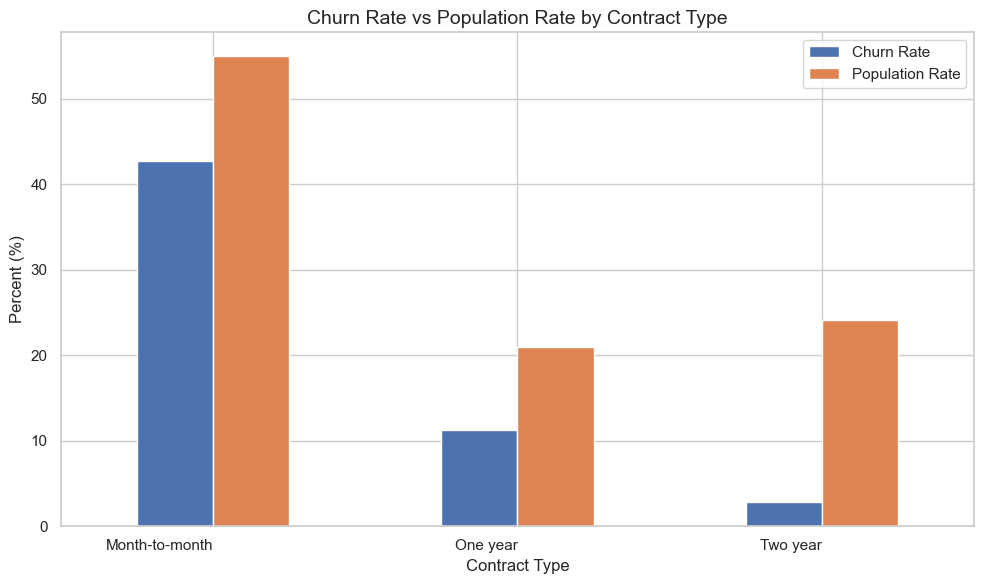

In [107]:
df_contract = df.groupby('Contract').agg({
    'Churn' : 'sum',
    'customerID':'count'})
df_contract['ChurnRate'] = round(((df_contract['Churn']/df_contract['customerID'])*100),2)
total_customers = df['customerID'].count()
df_contract['PopulationRate'] = round(((df_contract['customerID']/total_customers)*100),2)
df_contract
ax = df_contract[['ChurnRate', 'PopulationRate']].plot(kind='bar', figsize=(10,6))
ax.set_xticklabels(df_contract.index,rotation=0,ha='right')
plt.title('Churn Rate vs Population Rate by Contract Type', fontsize=14)
plt.ylabel('Percent (%)', fontsize=12)
plt.xlabel('Contract Type', fontsize=12)
plt.legend(['Churn Rate', 'Population Rate'])
plt.tight_layout()
plt.show()

In [108]:
len(df)

7043

In [109]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

## 2. Exploratory Data Analysis (EDA)

Before building a predictive model, let's see what the data itself tells us about the customers. We will analyze them from a financial and loyalty perspective.

**Key takeaways from the charts below:**
* **Tenure:** The highest risk of losing a customer occurs in the first few months. Customers with long tenure rarely leave.
* **Costs (MonthlyCharges):** The relationship is clear – higher monthly bills correlate with a higher chance of service cancellation.
* **Payment Type:** Customers paying via Electronic Check have the highest churn rate, whereas those with automatic/recurring payments are much more stable.

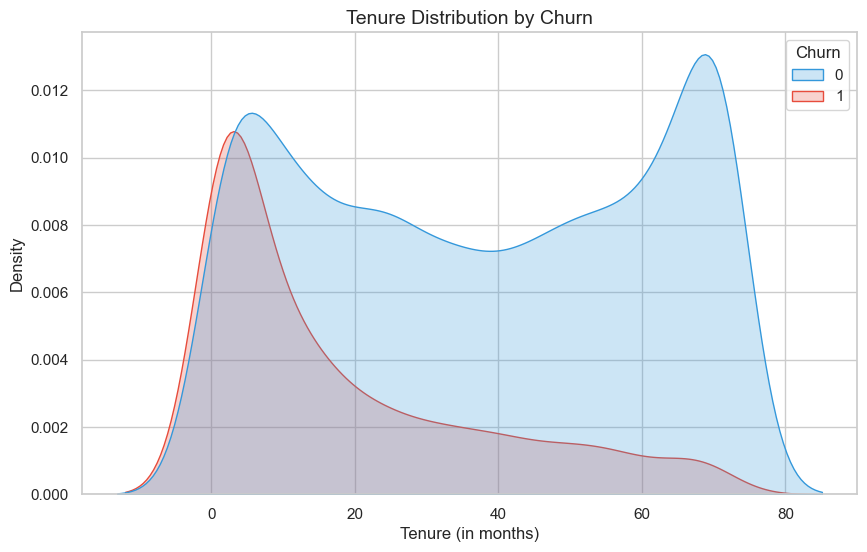

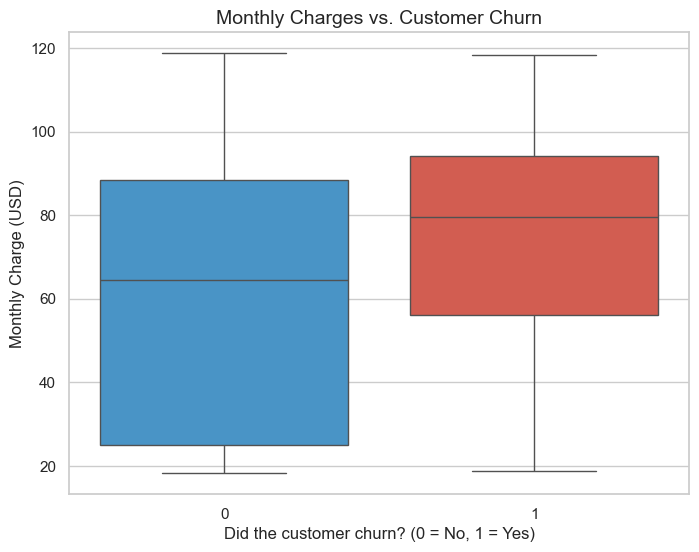

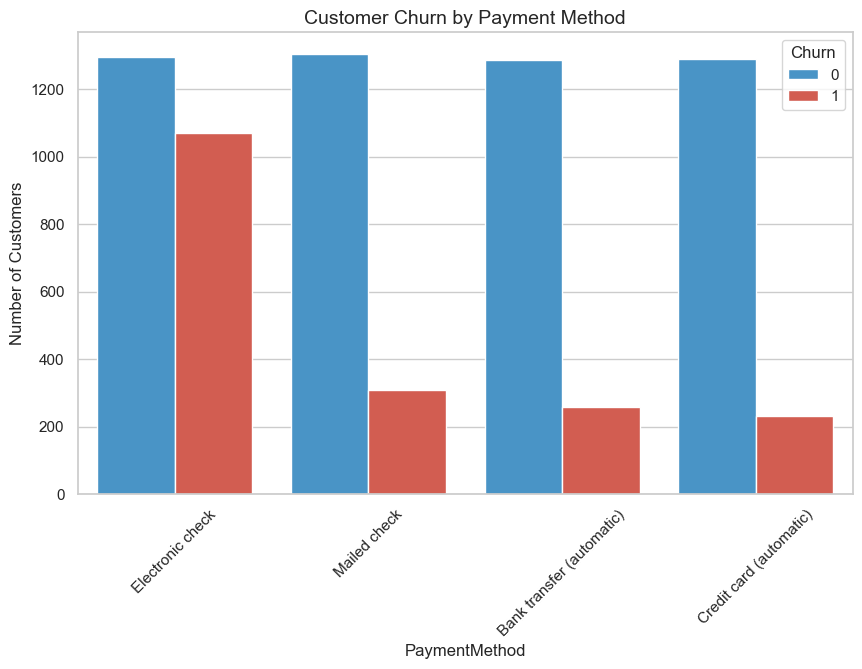

In [110]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette=['#3498db', '#e74c3c'])
plt.title('Tenure Distribution by Churn', fontsize=14)
plt.xlabel('Tenure (in months)')
plt.ylabel('Density')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#3498db', '#e74c3c'])
plt.title('Monthly Charges vs. Customer Churn', fontsize=14)
plt.xlabel('Did the customer churn? (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charge (USD)')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=['#3498db', '#e74c3c'])
plt.title('Customer Churn by Payment Method', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Number of Customers')
plt.show()

### The Impact of Services and Demographics on Churn

Let's check which additional services help "retain" a customer and whether family status matters for stability.

**Key takeaways:**
* **Additional services:** The lack of TechSupport and OnlineSecurity drastically increases the probability of churning.
* **The Fiber Optic Paradox:** The Fiber optic service records the highest churn rate (over 40%). This might suggest technical issues with the premium service or strong competition in this area.
* **Demographics:** Customers with a partner or Dependents are more stable – they change service providers less often.
* **Senior Citizens:** Customers identified as seniors churn more frequently. This could be due to the services or support systems not being well-adapted to the needs of older adults.

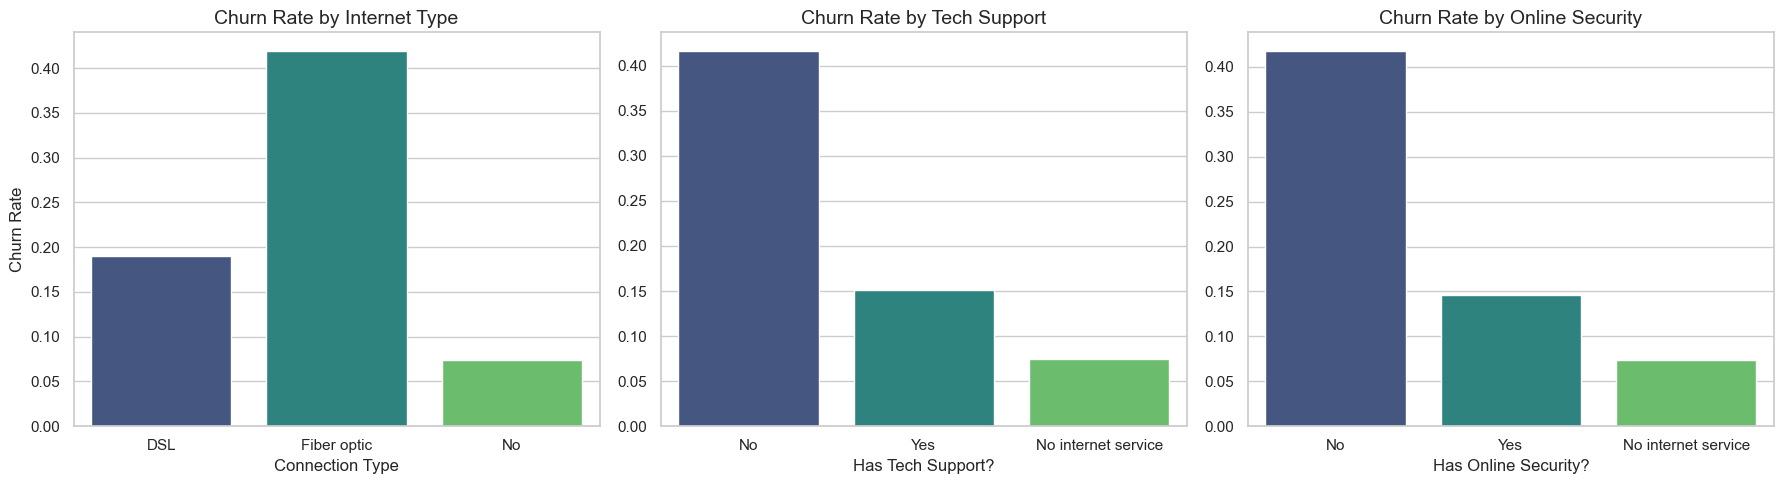

In [111]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x='InternetService', y='Churn', ax=axes[0], palette='viridis', errorbar=None)
axes[0].set_title('Churn Rate by Internet Type', fontsize=14)
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('Connection Type')

sns.barplot(data=df, x='TechSupport', y='Churn', ax=axes[1], palette='viridis', errorbar=None)
axes[1].set_title('Churn Rate by Tech Support', fontsize=14)
axes[1].set_ylabel('')
axes[1].set_xlabel('Has Tech Support?')

sns.barplot(data=df, x='OnlineSecurity', y='Churn', ax=axes[2], palette='viridis', errorbar=None)
axes[2].set_title('Churn Rate by Online Security', fontsize=14)
axes[2].set_ylabel('')
axes[2].set_xlabel('Has Online Security?')

plt.tight_layout()
plt.show()

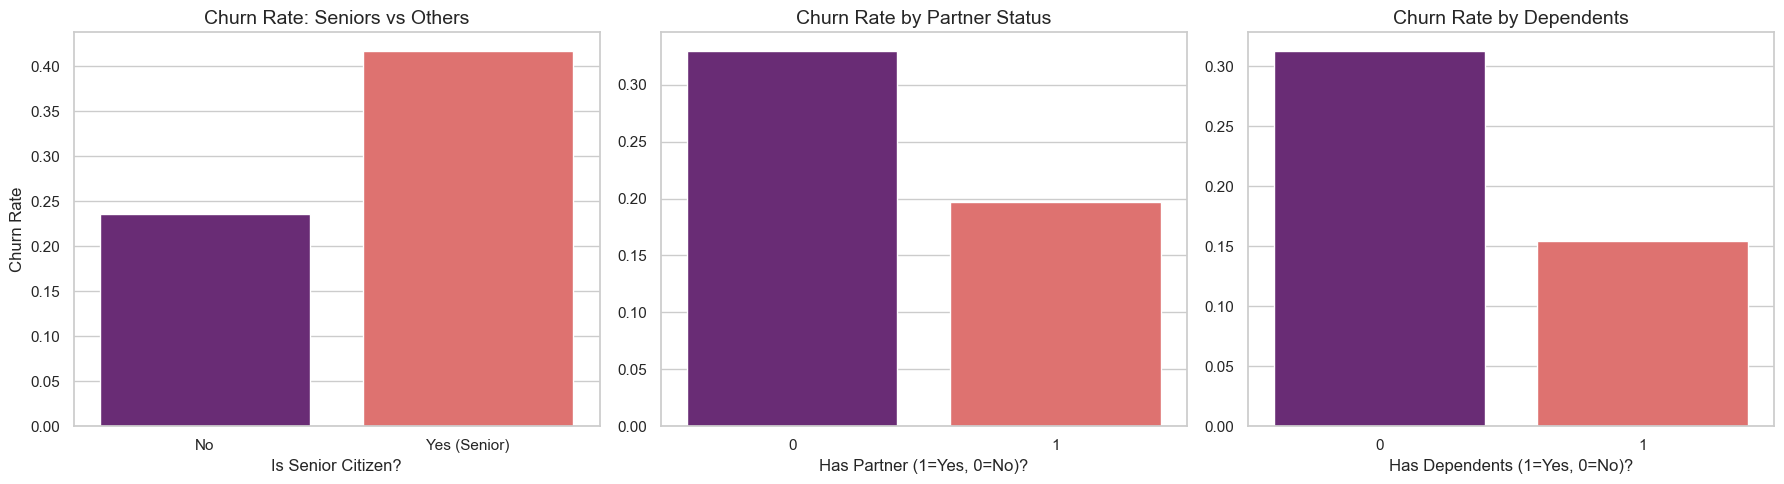

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Senior_Label'] = df['SeniorCitizen'].map({1: 'Yes (Senior)', 0: 'No'})

sns.barplot(data=df, x='Senior_Label', y='Churn', ax=axes[0], palette='magma', errorbar=None)
axes[0].set_title('Churn Rate: Seniors vs Others', fontsize=14)
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('Is Senior Citizen?')

sns.barplot(data=df, x='Partner', y='Churn', ax=axes[1], palette='magma', errorbar=None)
axes[1].set_title('Churn Rate by Partner Status', fontsize=14)
axes[1].set_ylabel('')
axes[1].set_xlabel('Has Partner (1=Yes, 0=No)?')

sns.barplot(data=df, x='Dependents', y='Churn', ax=axes[2], palette='magma', errorbar=None)
axes[2].set_title('Churn Rate by Dependents', fontsize=14)
axes[2].set_ylabel('')
axes[2].set_xlabel('Has Dependents (1=Yes, 0=No)?')

plt.tight_layout()
plt.show()

df = df.drop(columns=['Senior_Label'])

## 3. Data Preparation for Machine Learning

Before building the model, we need to encode the remaining text variables into a numerical format (so-called *One-Hot Encoding*). 

**Preventing Data Leakage:**
I consciously choose to split the dataset into training and testing sets (`train_test_split`) **before** applying categorical transformations. This guarantees that the test set remains completely isolated (as a simulation of the future), and the model does not peek at the distribution of categories outside the training set.

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
df = df.drop(columns=['customerID'])

categorical_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
                    'StreamingMovies', 'Contract', 'PaymentMethod']


In [114]:
X = df.drop(columns=['Churn'])
y= df['Churn']
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2,random_state = 42)

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True).astype(int)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True).astype(int)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

## 4. Model Building and Training (Random Forest vs XGBoost)

The problem of predicting customer churn is characterized by so-called **class imbalance** (significantly more customers stay than leave). To prevent the model from becoming "lazy" and ignoring the minority class of churning customers:
1. We will test a baseline model: **Random Forest** (with the `class_weight='balanced'` parameter).
2. We will test an advanced **XGBoost Classifier**, dynamically calculating class weights (the `scale_pos_weight` parameter) and using the `early_stopping_rounds` mechanism to prevent Overfitting.

In [115]:
rf_model = RandomForestClassifier(n_estimators = 500,random_state = 42,class_weight='balanced')
rf_model.fit(X_train,y_train)
y_pred = rf_model.predict(X_test)
print(f"Random Forest Model accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Classification Report:",classification_report(y_test,y_pred))

Random Forest Model accuracy: 0.78

Classification Report:               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1036
           1       0.63      0.46      0.53       373

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [116]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42,
                         max_depth=5,            
                         learning_rate=0.05,     
                         n_estimators=1000,       
                         subsample = 0.7,
                         reg_lambda = 1,
                         scale_pos_weight = scale_pos_weight,
                         early_stopping_rounds=20)

xgb_model.fit(X_train, y_train, eval_set=[(X_test,y_test)],verbose=50)

y_pred_xgb = xgb_model.predict(X_test)

print(f"XGBoost Model accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}\n")

print("Classification report XGBoost:")
print(classification_report(y_test, y_pred_xgb))

[0]	validation_0-logloss:0.67590
[50]	validation_0-logloss:0.47682
[100]	validation_0-logloss:0.46477
[150]	validation_0-logloss:0.46035
[200]	validation_0-logloss:0.45844
[207]	validation_0-logloss:0.45806
XGBoost Model accuracy: 0.77

Classification report XGBoost:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1036
           1       0.54      0.81      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



## 5. Model Evaluation (Business Trade-off)

Let's compare the results of both algorithms using confusion matrices. In the case of Customer Churn, our main metric is not the overall Accuracy, but the **Recall for class 1**, which is the model's ability to capture as many actually churning customers as possible.

Applying class weights in the **XGBoost** model led to an intentional compromise (*Precision-Recall Trade-off*). From a business perspective:
* We increased the number of captured churners at the cost of more "false alarms" (False Positives).
* **Financial justification:** The cost of offering, for example, a 10% discount to a customer who would have stayed with us anyway (mistakenly identified by the model) is significantly lower than the cost of completely losing the margin from a customer the model would have missed.

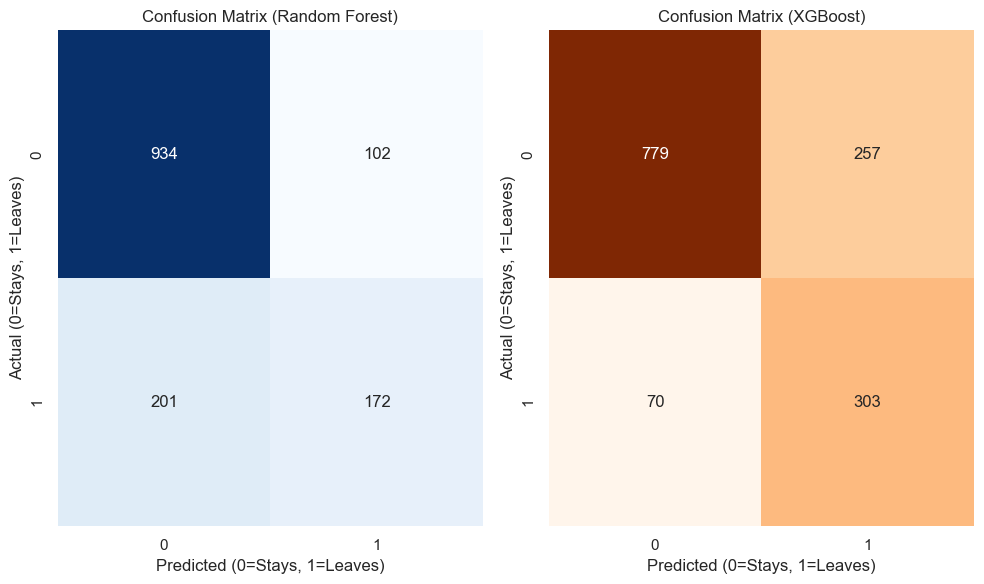

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

cm_rf = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix (Random Forest)')
axes[0].set_xlabel('Predicted (0=Stays, 1=Leaves)')
axes[0].set_ylabel('Actual (0=Stays, 1=Leaves)')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1]) 
axes[1].set_title('Confusion Matrix (XGBoost)')
axes[1].set_xlabel('Predicted (0=Stays, 1=Leaves)')
axes[1].set_ylabel('Actual (0=Stays, 1=Leaves)')

plt.tight_layout()
plt.show()

## 6. What drives customers to leave? (Feature Importance)

For the model to be useful to the business, it cannot be a "black box". Let's check which features both algorithms paid the most attention to when making the decision to label a customer as "churning".

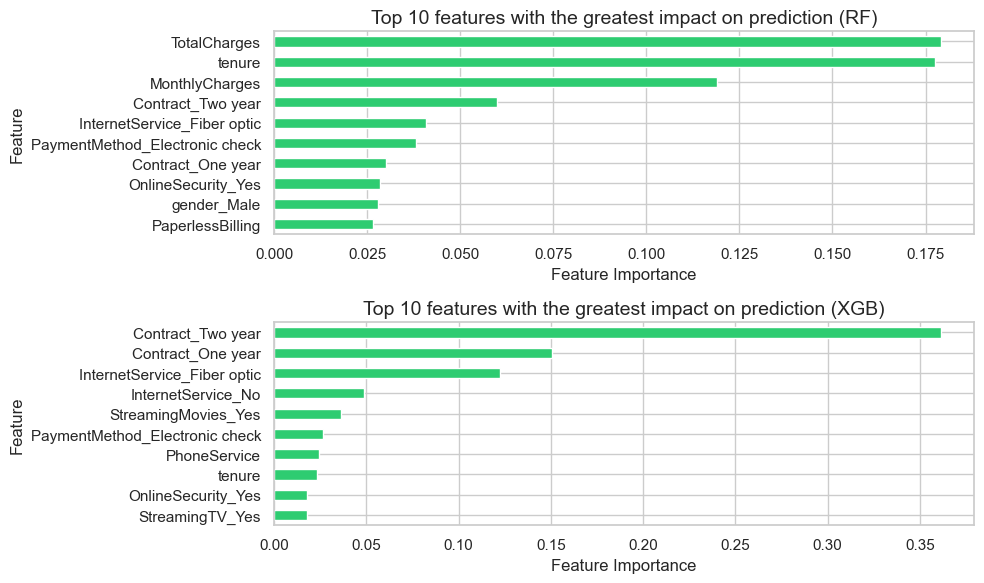

In [118]:
feature_importances_rf = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

top_10_features_rf = feature_importances_rf.nlargest(10)
top_10_features_xgb = feature_importances_xgb.nlargest(10)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

top_10_features_rf.sort_values().plot(kind='barh', color='#2ecc71', ax=axes[0])
axes[0].set_title('Top 10 features with the greatest impact on prediction (RF)', fontsize=14)
axes[0].set_xlabel('Feature Importance')
axes[0].set_ylabel('Feature')

top_10_features_xgb.sort_values().plot(kind='barh', color='#2ecc71', ax=axes[1])
axes[1].set_title('Top 10 features with the greatest impact on prediction (XGB)', fontsize=14)
axes[1].set_xlabel('Feature Importance')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

## Summary and Business Recommendations

The machine learning models revealed a consistent, yet varied picture of the factors influencing customer decisions. The Random Forest algorithm focused on continuous variables (costs and time), while the optimized XGBoost isolated key service categories. 

Based on the *Feature Importance* analysis of both models, the following recommendations were drawn for the customer retention department:

1. **Long-term contracts are the foundation of loyalty:** Both `Contract_Two year` and `Contract_One year` were at the very top of the XGBoost model, and two-year contracts ranked high in Random Forest. This means that the lack of such a contract (i.e., using the *Month-to-month* option) is the biggest risk factor. **Recommendation:** Direct the main promotional budgets towards encouraging customers to sign 12- or 24-month contracts (e.g., by offering the first month for free).
2. **Costs and price sensitivity:** Random Forest clearly indicated that total costs (`TotalCharges`) and monthly bills (`MonthlyCharges`) are the main reasons for leaving, right next to short tenure (`tenure`). **Recommendation:** The customer retention department should proactively contact customers with a short tenure who have the most expensive packages, offering them, for example, a loyalty discount after 3 months.
3. **The Fiber Optic problem:** The XGBoost algorithm identified `InternetService_Fiber optic` as one of the most important features. This confirms the conclusions from the exploratory data analysis (EDA) – paradoxically, the premium service generates the highest cancellations. **Recommendation:** An urgent audit by the technical department to check the reliability of the fiber optic connection, along with a verification of the pricing policy compared to local competition.
4. **"Phone Only" customers are a stable base:** The high ranking of the `InternetService_No` feature in the XGBoost model means that customers who only have the simplest services with the company (no internet, likely just a phone line) are the most stable, non-churning group.